In [71]:
# Se cargan las bibliotecas de pandas, numpy y matplotlib
import pandas as pd 
from pandas import ExcelWriter
from pandas import ExcelFile
import numpy as np
import matplotlib. pyplot as plt
from scipy import stats
from scipy.stats import anderson, normaltest, probplot, t
import time
from tabulate import tabulate

print("Bibliotecas importadas correctamente")

Bibliotecas importadas correctamente


In [72]:
start = time.time()

# Cargar los datos desde el archivo Excel
# BPM originales
df_orig = pd.read_excel("Dataset.xlsx")
Tiempo = df_orig["Tiempo(s)"].values
BPM_orig = df_orig["BPM"].round().astype(int).values

# Cargar los datos desde el archivo Excel
# BPM decodificados
df = pd.read_excel('Dataset_Decodificados.xlsx', header=0)
BER = "BER"
DatosBER = df["BER"]

# BPM decodificados desde archivos de texto
BPM_dec_74 = np.loadtxt("Datos_decodificados/BPM_decodificados_7_4.txt", dtype=int)
BPM_dec_1511 = np.loadtxt("Datos_decodificados/BPM_decodificados_15_11.txt", dtype=int)

In [73]:
# Construir un DataFrame
df = pd.DataFrame({
    "Tiempo(s)": Tiempo,
    "BPM_original": BPM_orig,
    "BPM_7_4": BPM_dec_74,
    "BPM_15_11": BPM_dec_1511
})

In [74]:
# Zonas de Entrenamiento
DatosLatidos = df["BPM_original"]
DatosTiempo = df["Tiempo(s)"]

FCmax = DatosLatidos.max()
Z1 = round(FCmax * 0.65, 2)
Z2 = round(FCmax * 0.80, 2)
Z3 = round(FCmax * 0.85, 2)
Z4 = round(FCmax * 0.95, 2)

Zona1T, Zona1L = [], []
Zona2T, Zona2L = [], []
Zona3T, Zona3L = [], []
Zona4T, Zona4L = [], []
Zona5T, Zona5L = [], []

for t, bpm in zip(DatosTiempo, DatosLatidos):
    if bpm < 0:
        continue
    elif 0 < bpm <= Z1:                  # Zona 1
        Zona1T.append(t)
        Zona1L.append(bpm)
    elif Z1 < bpm <= Z2:                 # Zona 2
        Zona2T.append(t)
        Zona2L.append(bpm)
    elif Z2 < bpm <= Z3:                 # Zona 3
        Zona3T.append(t)
        Zona3L.append(bpm)
    elif Z3 < bpm <= Z4:                 # Zona 4
        Zona4T.append(t)
        Zona4L.append(bpm)
    else:                                # Zona 5
        Zona5T.append(t)
        Zona5L.append(bpm)

In [75]:
headers = ["Tiempo (s)", "BPM"]

tablaZ1 = tabulate(list(zip(Zona1T, Zona1L)), headers, tablefmt="grid")
tablaZ2 = tabulate(list(zip(Zona2T, Zona2L)), headers, tablefmt="grid")
tablaZ3 = tabulate(list(zip(Zona3T, Zona3L)), headers, tablefmt="grid")
tablaZ4 = tabulate(list(zip(Zona4T, Zona4L)), headers, tablefmt="grid")
tablaZ5 = tabulate(list(zip(Zona5T, Zona5L)), headers, tablefmt="grid")

print("Tablas resultante para cada zona de BPM\n")
print("Zona 1: Calentamiento:\n", tablaZ1)
print("Zona 2: Quema Grasa:\n", tablaZ2)
print("Zona 3: Aeróbica:\n", tablaZ3)
print("Zona 4: Anaeróbica:\n", tablaZ4)
print("Zona 5: Esfuerzo máximo:\n", tablaZ5)

Tablas resultante para cada zona de BPM

Zona 1: Calentamiento:
 +--------------+-------+
|   Tiempo (s) |   BPM |
+==============+=======+
|            0 |    90 |
+--------------+-------+
|           10 |    91 |
+--------------+-------+
|           20 |    93 |
+--------------+-------+
|           30 |    92 |
+--------------+-------+
|           40 |    93 |
+--------------+-------+
|           50 |    97 |
+--------------+-------+
|           60 |    94 |
+--------------+-------+
|           70 |    96 |
+--------------+-------+
|           80 |    97 |
+--------------+-------+
|           90 |    98 |
+--------------+-------+
|          100 |   100 |
+--------------+-------+
|          110 |   101 |
+--------------+-------+
|          120 |   102 |
+--------------+-------+
|          130 |   102 |
+--------------+-------+
|          140 |   102 |
+--------------+-------+
|          150 |   102 |
+--------------+-------+
|          160 |   104 |
+--------------+-------+
|         

In [76]:
resumen_zonas = [
    ["Zona 1", "Calentamiento",         f"< {Z1:.2f} bpm"],
    ["Zona 2", "Quema de grasa",        f"{Z1:.2f} – {Z2:.2f} bpm"],
    ["Zona 3", "Aeróbica",              f"{Z2:.2f} – {Z3:.2f} bpm"],
    ["Zona 4", "Anaeróbica",            f"{Z3:.2f} – {Z4:.2f} bpm"],
    ["Zona 5", "Esfuerzo máximo", f"> {Z4:.2f} bpm"],
]

In [77]:
# ===================== 4. Resultados en texto =====================

print("Las zonas de frecuencia cardíaca son:\n")
print("BPM máximo: ", FCmax)
print("Zona 1: Calentamiento : Inferior a", Z1)
print("Zona 2: Quema Grasa: Entre", Z1, "y", Z2)
print("Zona 3: Aeróbica: Entre", Z2, "y", Z3)
print("Zona 4: Anaeróbica: Entre", Z3, "y", Z4)
print("Zona 5: Esfuerzo máximo: Superior a", Z4, "\n")
print(" ----------------------------------------\n")

print("Tabla resumen de zonas de frecuencia cardíaca\n")
print(tabulate(
    resumen_zonas,
    headers=["Zona", "Descripción", "Rango de FC [BPM]"],
    tablefmt="grid"
))
print(" ----------------------------------------")

Las zonas de frecuencia cardíaca son:

BPM máximo:  165
Zona 1: Calentamiento : Inferior a 107.25
Zona 2: Quema Grasa: Entre 107.25 y 132.0
Zona 3: Aeróbica: Entre 132.0 y 140.25
Zona 4: Anaeróbica: Entre 140.25 y 156.75
Zona 5: Esfuerzo máximo: Superior a 156.75 

 ----------------------------------------

Tabla resumen de zonas de frecuencia cardíaca

+--------+-----------------+---------------------+
| Zona   | Descripción     | Rango de FC [BPM]   |
+========+=================+=====================+
| Zona 1 | Calentamiento   | < 107.25 bpm        |
+--------+-----------------+---------------------+
| Zona 2 | Quema de grasa  | 107.25 – 132.00 bpm |
+--------+-----------------+---------------------+
| Zona 3 | Aeróbica        | 132.00 – 140.25 bpm |
+--------+-----------------+---------------------+
| Zona 4 | Anaeróbica      | 140.25 – 156.75 bpm |
+--------+-----------------+---------------------+
| Zona 5 | Esfuerzo máximo | > 156.75 bpm        |
+--------+-----------------+----

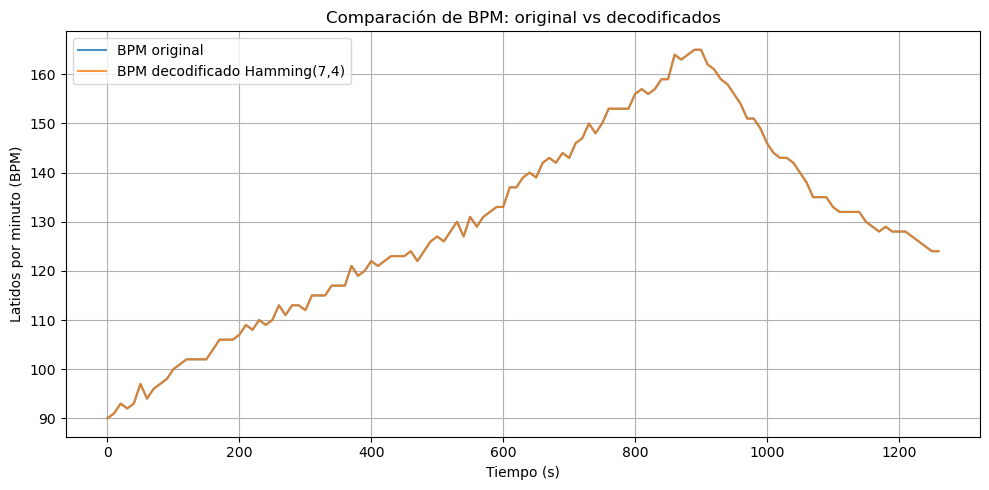

In [83]:
# ===================== 5. Gráfica de Latidos (original vs decodificados) =====================

plt.figure(figsize=(10, 5))
plt.plot(Tiempo, BPM_orig, label="BPM original", alpha=0.8)
plt.plot(Tiempo, BPM_dec_74, label="BPM decodificado Hamming(7,4)", alpha=0.8)
#plt.plot(Tiempo, BPM_dec_1511, label="BPM decodificado Hamming(15,11)", alpha=0.8)
plt.xlabel("Tiempo (s)")
plt.ylabel("Latidos por minuto (BPM)")
plt.title("Comparación de BPM: original vs decodificados")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

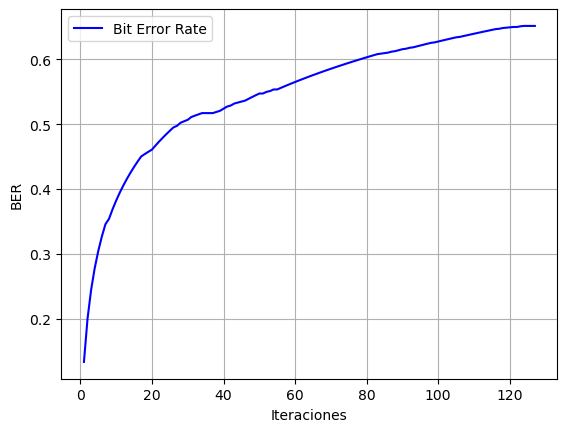

In [79]:
 #---------- Gráfica de Bit Error Rate----------

Iteraciones = []
DatosBER_req = list(DatosBER[0:127])
cont = 1

for i in DatosBER:
    if i > 0:
        Iteraciones.append(cont)
        cont = cont+1
    else:
        continue

plt.figure()
plt.plot(Iteraciones, DatosBER_req,color='b', label="Bit Error Rate")
plt.xlabel("Iteraciones")
plt.ylabel("BER")
plt.legend()
plt.grid()
plt.show()

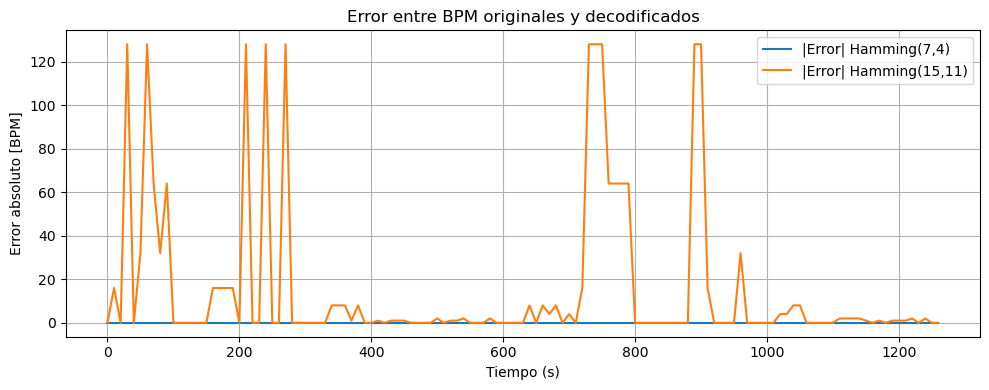


Tiempo de ejecución del bloque de visualización: 0.39032578468322754 s


In [80]:
error_74 = np.abs(BPM_orig - BPM_dec_74)
error_1511 = np.abs(BPM_orig - BPM_dec_1511)

plt.figure(figsize=(10, 4))
plt.plot(Tiempo, error_74, label="|Error| Hamming(7,4)")
plt.plot(Tiempo, error_1511, label="|Error| Hamming(15,11)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Error absoluto [BPM]")
plt.title("Error entre BPM originales y decodificados")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

end = time.time()
print('\nTiempo de ejecución del bloque de visualización:', end - start, 's')